# 02 - Modeling

**Building seven uplift learners and choosing one without cheating**

Notebook 01 established the problem: the campaign wants users whose behaviour
*changes*, and that quantity is never observed for anybody. This notebook
builds the candidate models and, more importantly, builds the protocol that
decides between them.

What this notebook covers:

1. What can be trained when the label does not exist
2. The three-stage split, fixed before any data is seen
3. Cross-fitting, and how it differs from cross-validation
4. Seven candidate learners from two different families
5. Running the full selection pipeline
6. Reading the selection table and picking a champion
7. Comparing against the locked run that the project actually reports

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.criteo import load_criteo
from src.experiments.honest_uplift import run_honest_uplift_experiment
from src.experiments.splitting import split_train_validation_test
from src.models.registry import REFERENCE_POLICIES, select_model_factories

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 9,
    }
)
TEAL, GREY, CORAL = "#0E6E64", "#8A8A80", "#C1553B"

## 1. What can be trained when the label does not exist

For a normal classifier the recipe is: take features, take labels, minimise a
loss. Here the label

$$\text{uplift}(X) = P(Y = 1 \mid X, T = 1) - P(Y = 1 \mid X, T = 0)$$

is a difference between two worlds and each user only lives in one of them.

There are two ways around it, and the project implements both so they can be
compared on equal terms:

**Outcome modelling.** Fit models that predict the outcome, then subtract
their predictions. The subtraction happens at prediction time, so the model
never needs the missing label.

**Label transformation.** Build a synthetic target whose conditional
expectation equals the uplift, then run an ordinary regression on it. The
transformation uses the known assignment probability, which is available here
precisely because the design is randomized.

| Family | Learner | Idea in one line |
|---|---|---|
| Outcome modelling | S-learner | One model, treatment is just another feature |
| Outcome modelling | T-learner | Two separate models, one per arm |
| Outcome modelling | X-learner | T-learner, then impute and correct with propensity weights |
| Label transformation | CVT | Relabel so that a classifier on the new label recovers uplift |
| Label transformation | Transformed outcome | Divide the label by the assignment probability, then regress |
| Label transformation | R-learner | Residualise outcome and treatment, then regress one on the other |
| Label transformation | DR-learner | Regress on a doubly robust pseudo-outcome |

Plus the incumbent, `response_model`, which ranks by predicted response, and
`random_targeting`, which ranks at random and exists to audit the estimator.

## 2. The three-stage split

The risk this protocol exists to prevent is simple. If the same data both
picks the model and reports its performance, the reported number is optimistic
by an unknown amount. The project's earlier prototype hit exactly this and
produced an improvement figure that did not survive a clean split.

So the data is cut three ways, stratified on the joint treatment and outcome
strata so all four combinations keep their proportions:

| Stage | Share | Purpose | May be used again? |
|---|---:|---|---|
| Train | 60% | Fit candidates and nuisance models | yes |
| Validation | 20% | Choose the champion | yes |
| Locked test | 20% | Report the number, once | **no** |

Three things were fixed before any data was seen: the operating budget of 5%,
the confidence level of 95%, and the selection rule.

In [2]:
SAMPLE = ROOT / "data" / "processed" / "criteo_sample_500k.parquet"
dataset = load_criteo(SAMPLE, outcome="visit")
splits = split_train_validation_test(dataset, random_state=42)

split_table = pd.DataFrame(
    [
        {
            "stage": name,
            "rows": len(part.y),
            "share_pct": 100 * len(part.y) / len(dataset.y),
            "treated_pct": 100 * part.treatment.mean(),
            "visit_pct": 100 * part.y.mean(),
        }
        for name, part in [
            ("train", splits.train),
            ("validation", splits.validation),
            ("test (locked)", splits.test),
        ]
    ]
)
split_table

,stage,rows,share_pct,treated_pct,visit_pct
0,train,300000,60.0,85.010333,4.759333
1,validation,100000,20.0,85.011000,4.760000
2,test (locked),100000,20.0,85.010000,4.759000


The treatment share and outcome rate are near identical across the three
partitions, which is what stratifying on the joint strata buys. A split that
drifted here would make the three stages incomparable.

## 3. Cross-fitting, and why it is not cross-validation

The evaluation in notebook 03 needs two nuisance models, one predicting the
outcome under treatment and one under control. If those are fitted on the same
rows they later score, they overfit, the residual `Y - mu(X)` shrinks, and the
confidence interval comes out too narrow. The estimate looks more certain than
the data supports.

Cross-fitting prevents that: the data is split into folds, and every row is
scored by a model that never saw it.

This uses the same mechanics as k-fold cross-validation but answers a
different question, and the project keeps the two words separate on purpose:

| | Cross-validation | Cross-fitting |
|---|---|---|
| Question | Which hyperparameter is best? | What is an unbiased prediction for this row? |
| Output used | A score to compare settings | The out-of-fold predictions themselves |
| Used here for | Nothing, no tuning is done | Nuisance models and candidate scores |

## 4. One fixed model configuration

No hyperparameter tuning happens anywhere in this project. That is deliberate,
and it is worth separating the part of it that is justified from the part that
is a cost.

The evaluator used in notebook 03 is doubly robust: it is unbiased if *either*
the outcome models are right *or* the propensity is right. Here the design is
randomized, so the propensity is known exactly rather than estimated. That
condition holds by construction, and the estimate stays unbiased however badly
the nuisance models fit. The evaluator's fixed configuration therefore costs
precision, not correctness.

The candidates are a different matter. Their configuration is held fixed so
that differences between them come from the learner rather than from search
effort, which is a fair-comparison argument rather than a correctness one. Six
of the seven run on one LightGBM configuration; the seventh,
transformed-outcome, uses ridge, because at this propensity its regression
target takes only three values and a flexible learner fits those spikes.

What that costs is measured rather than assumed. `04_base_learners.ipynb`
rebuilds all seven candidates on three different estimator families and reports
how far the winner moves.

In [3]:
MODEL_NAMES = [
    "response_model",
    "s_learner",
    "t_learner",
    "x_learner",
    "cvt",
    "transformed_outcome",
    "r_learner",
    "dr_learner",
]
factories = select_model_factories(MODEL_NAMES, crossfit_folds=5)

print(f"Candidate learners : {len(factories)}")
print(f"Reference policies : {REFERENCE_POLICIES}")
print(f"Can win selection  : "
      f"{[n for n in factories if n not in REFERENCE_POLICIES]}")

Candidate learners : 9
Reference policies : ('response_model', 'random_targeting')
Can win selection  : ['s_learner', 't_learner', 'x_learner', 'cvt', 'transformed_outcome', 'r_learner', 'dr_learner']


## 5. Running the pipeline

One call runs the whole protocol: fit every candidate on training data,
produce out-of-fold scores across three selection folds on the combined
development data, apply the selection rule, refit the winner on train plus
validation, and open the locked test exactly once.

This takes a few minutes. The progress lines below show each learner being
fitted at each stage.

In [4]:
started = time.time()
result = run_honest_uplift_experiment(
    dataset,
    model_factories=factories,
    train_fraction=0.60,
    validation_fraction=0.20,
    budgets=(0.05, 0.10, 0.20, 0.30),
    primary_budget=0.05,
    confidence_level=0.95,
    random_state=42,
    selection_folds=3,
    progress=print,
)
print(f"\nTotal wall clock: {time.time() - started:.1f} s")

selection_fold_1: random_targeting
selection_fold_1: response_model


selection_fold_1: s_learner


selection_fold_1: t_learner


selection_fold_1: x_learner


selection_fold_1: cvt


...

selection_fold_3: transformed_outcome
selection_fold_3: r_learner


selection_fold_3: dr_learner


locked_test: response_model


locked_test: random_targeting
locked_test: s_learner



Total wall clock: 610.0 s


In [5]:
print(f"Champion selected      : {result.champion}")
print(f"Selection folds        : {result.selection_folds}")
print(f"Selection observations : {result.selection_size:,}")
print(f"Primary budget         : {100 * result.primary_budget:.0f}%")

Champion selected      : s_learner
Selection folds        : 3
Selection observations : 400,000
Primary budget         : 5%


## 6. Reading the selection table

The rule was fixed in advance: **take the candidate with the largest lower
confidence bound on the paired difference against response targeting, at the
5% budget.**

Two details in that sentence matter.

*Lower bound, not point estimate.* A candidate with a big point estimate and a
huge interval is not evidence of anything. Ranking on the lower bound prefers
candidates that are both good and measured precisely.

*Paired difference.* The comparison is computed per user as
`[pi_uplift(X) - pi_response(X)] * phi`, not as the difference of two
separately estimated policy values. At a 5% budget the two policies select
largely the same people, and those users cancel in the pairing, leaving
uncertainty only where the policies disagree.

In [6]:
PRIMARY = 5.0
selection = (
    result.validation_contrasts[
        np.isclose(result.validation_contrasts["budget_pct"], PRIMARY)
    ]
    .merge(result.validation_metrics, on="policy", how="left")
    .sort_values("ci_lower", ascending=False)
    .reset_index(drop=True)
)
selection[
    ["policy", "difference", "ci_lower", "ci_upper", "benchmark_relative_auuc"]
]

,policy,difference,ci_lower,ci_upper,benchmark_relative_auuc
0,s_learner,612.372289,276.440164,948.304415,0.008539
1,x_learner,587.553991,273.160690,901.947291,0.007726
2,transformed_outcome,455.301828,132.673515,777.930140,0.008685
3,t_learner,418.579933,95.289699,741.870168,0.007775
4,dr_learner,310.788052,-2.413888,623.989993,0.007671
5,r_learner,302.312837,-14.557861,619.183535,0.007438
6,cvt,-311.278937,-622.421428,-0.136447,0.006070
7,random_targeting,-969.147331,-1340.346829,-597.947833,0.005126


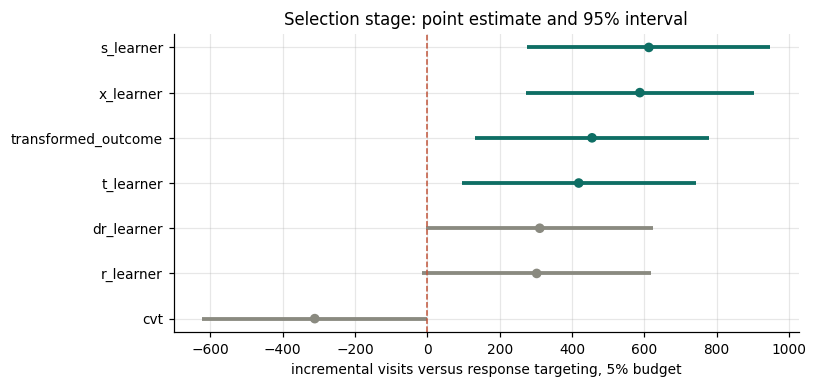

Candidates whose interval clears zero: ['s_learner', 'x_learner', 'transformed_outcome', 't_learner']


In [7]:
plot_data = selection[selection["policy"] != "random_targeting"].iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
positions = np.arange(len(plot_data))
clears_zero = plot_data["ci_lower"] > 0
colors = np.where(clears_zero, TEAL, GREY)

ax.hlines(positions, plot_data["ci_lower"], plot_data["ci_upper"],
          color=colors, linewidth=2.5)
ax.scatter(plot_data["difference"], positions, color=colors, zorder=3, s=28)
ax.axvline(0, color=CORAL, linestyle="--", linewidth=1)
ax.set_yticks(positions)
ax.set_yticklabels(plot_data["policy"])
ax.set_xlabel("incremental visits versus response targeting, 5% budget")
ax.set_title("Selection stage: point estimate and 95% interval")
fig.tight_layout()
plt.show()

winners = selection.loc[selection["ci_lower"] > 0, "policy"].tolist()
print(f"Candidates whose interval clears zero: {winners if winners else 'none'}")

### What the leaderboard does and does not say

The rule always returns a name, because it ranks candidates rather than
requiring one to clear a bar. So a candidate at the top of this table is not
automatically better than the one below it. Notebook 03 measures how close the
call actually was, across ten repeated splits, and that measurement is what
decides how strongly the choice can be stated.

In [8]:
ranking = selection[["policy", "difference", "ci_lower"]].copy()
ranking["rank"] = np.arange(1, len(ranking) + 1)
gap_to_second = (
    ranking.loc[0, "ci_lower"] - ranking.loc[1, "ci_lower"]
    if len(ranking) > 1
    else float("nan")
)
half_width = (
    selection.loc[0, "ci_upper"] - selection.loc[0, "difference"]
)
print(f"Top candidate            : {ranking.loc[0, 'policy']}")
print(f"Gap to runner-up (bound) : {gap_to_second:,.1f}")
print(f"Half-width of its own CI : {half_width:,.1f}")
print(f"Gap as a share of that   : {gap_to_second / half_width:.2f}")

Top candidate            : s_learner
Gap to runner-up (bound) : 3.3
Half-width of its own CI : 335.9
Gap as a share of that   : 0.01


## 7. Cost versus benefit across learners

Fit time is not a headline metric, but it answers a fair question: does the
more elaborate machinery pay for itself?

In [9]:
timing = (
    result.timing_table.groupby("model", as_index=False)["fit_seconds"]
    .sum()
    .sort_values("fit_seconds", ascending=False)
)
timing_vs_score = timing.merge(
    selection[["policy", "ci_lower"]], left_on="model", right_on="policy",
    how="left"
).drop(columns="policy")
timing_vs_score

,model,fit_seconds,ci_lower
0,dr_learner,178.635976,-2.413888
1,r_learner,172.426462,-14.557861
2,x_learner,71.064356,273.160690
3,response_model,34.798127,NaN
4,t_learner,34.717688,95.289699
5,aipw_nuisance_t_learner,30.744026,NaN
6,s_learner,28.901105,276.440164
7,cvt,25.661127,-622.421428
8,transformed_outcome,0.599054,132.673515
9,random_targeting,0.000802,-1340.346829


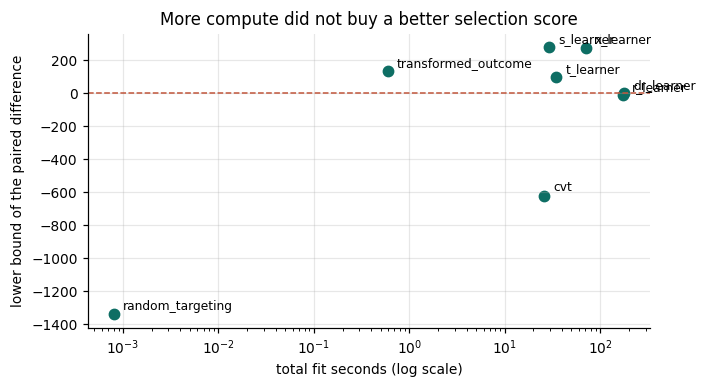

In [10]:
plotted = timing_vs_score.dropna(subset=["ci_lower"])
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.scatter(plotted["fit_seconds"], plotted["ci_lower"], color=TEAL, s=45)
for _, row in plotted.iterrows():
    ax.annotate(row["model"], (row["fit_seconds"], row["ci_lower"]),
                textcoords="offset points", xytext=(6, 3), fontsize=8)
ax.axhline(0, color=CORAL, linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("total fit seconds (log scale)")
ax.set_ylabel("lower bound of the paired difference")
ax.set_title("More compute did not buy a better selection score")
fig.tight_layout()
plt.show()

## 8. The run the project actually reports

Everything above ran on the 500,000 row development sample so that the
notebook executes in a few minutes. The number the project reports comes from
a larger locked run on the 1,000,000 row audit sample, stored in `outputs/`.

Loading it here keeps this notebook honest about which figures are
illustrative and which are the record.

In [11]:
locked = pd.read_csv(ROOT / "outputs" / "tables" / "audit_visit_selection.csv")
locked_primary = (
    locked[np.isclose(locked["budget_pct"], PRIMARY)]
    .sort_values("ci_lower", ascending=False)
    .reset_index(drop=True)
)
locked_primary[["policy", "incremental_outcome", "ci_lower", "ci_upper"]].head(9)

,policy,incremental_outcome,ci_lower,ci_upper
0,s_learner,3925.912961,3484.681153,4367.144769
1,transformed_outcome,3289.518281,2874.313371,3704.723192
2,x_learner,3320.809352,2874.172353,3767.446350
3,dr_learner,3265.573726,2824.319473,3706.827979
4,r_learner,3134.720986,2689.882864,3579.559107
5,t_learner,3036.810749,2590.499745,3483.121752
6,response_model,2997.945832,2489.169415,3506.722248
7,cvt,2515.766754,2102.576519,2928.956989
8,random_targeting,319.883211,146.468127,493.298295


In [12]:
comparison = pd.DataFrame(
    [
        {
            "run": "this notebook",
            "sample": "criteo_sample_500k.parquet",
            "rows": len(dataset.y),
            "selection_obs": result.selection_size,
            "champion": result.champion,
        },
        {
            "run": "locked run in outputs/",
            "sample": "criteo_audit_1m.parquet",
            "rows": 1_000_000,
            "selection_obs": 800_000,
            "champion": "s_learner",
        },
    ]
)
comparison

,run,sample,rows,selection_obs,champion
0,this notebook,criteo_sample_500k.parquet,500000,400000,s_learner
1,locked run in outputs/,criteo_audit_1m.parquet,1000000,800000,s_learner


The size of the selection sample is not a detail. An earlier version of the
project's stability experiment ran its selection stage on 100,000 observations
while the run that actually chose the champion used 800,000. Since the
selection stage was the thing being measured, the mismatch made the rule look
unstable when the real cause was the smaller sample. The lesson is recorded
here because this notebook makes the same tradeoff deliberately, for speed,
and says so.

## Summary

| Decision | Choice | Reason |
|---|---|---|
| What to train | Seven learners, two families | Compare approaches on equal terms rather than assume one |
| Hyperparameters | One fixed configuration, no tuning | Correct for the evaluator, a fair-comparison choice for the candidates, and measured in notebook 04 |
| How to split | 60/20/20, stratified on treatment by outcome | Selecting and reporting on the same data inflates the result |
| Nuisance predictions | Cross-fitted | In-fold predictions shrink residuals and narrow intervals falsely |
| Selection criterion | Largest lower bound on the paired difference at 5% | Rewards being both good and precisely measured |
| What test data is used for | Opened once, after everything is locked | Nothing remains to change one's mind with |

Notebook 03 evaluates the locked champion and quantifies how much the
selection itself can be trusted. Notebook 04 asks the question this section
left open: whether the champion survives changing the estimator underneath it.